The following code is for the graphs in the paper. Majority of the work is done by the __init__ in the LoktaVolterraModel class. 

In [1]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint,dblquad
import matplotlib.gridspec as gridspec
import logging 
from tabulate import tabulate

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
plt.rcParams["text.latex.preamble"] += r"\usepackage{amssymb}"

The all encompassing class structure for the general model. It plots the ode and the sde model. NOTE: T1 -  Evasive Tumor, T2- Baseline Tumor, B,dWt - Brownian motion

In [ ]:
# Class for the Lotka-Volterra Model

class LotkaVolterraModel:
    # Just initialing does everything but ode_details. bad coding etiquette but worked for me. 
    def __init__(self, r, gamma, alpha, beta, a, b, delta, p,q, K, nu, sigma, R_0, S_0, I_0, C_0 , inital_proportion_a_n, initial_e_b, T, steps ,cstar, plot):
        self.r = r
        self.gamma = gamma
        self.alpha = alpha
        self.beta = beta
        self.a = a
        self.b = b
        self.delta = delta
        self.K = K
        self.nu = nu
        self.sigma = sigma
        self.initial_conditions = [R_0, S_0, I_0]
        self.dt = T/steps
        self.p = p
        self.q = q
        # Time points on which all the compartments are solved in
        self.T = T
        self.t = np.linspace(0, T, steps)
        self.N = len(self.t)
        
        self.cstar = cstar
        self.inital_proportion_a_n = inital_proportion_a_n
        self.initial_e_b = initial_e_b
        self.apoptotic_start , self.necrotic_start = (C_0 * self.inital_proportion_a_n)/self.cstar, (C_0 * (1-self.inital_proportion_a_n))/self.cstar
        self.evasive_start , self.baseline_start = (C_0 * self.initial_e_b)/self.cstar, (C_0 * (1-self.initial_e_b))/self.cstar
        
        #Fake Normalization for  Biomarker abundance levels. Keep zero but idk if it does anything. It was a failed idea
        self.fake = 0
        
        # Solves the General Lotka-Volterra model and adds the results in the class variables
        self.solve(self.t)
        
        '''
        The Following code then generates all the paths using different assumptions for the noise and functional 
        form of the drift. The lists are then fed to a plot method to generate the pretty plots
        '''
        
        # Solve the Necrosis and Apoptosis  Biomarker compartments using IID noise numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a matrix with brownian steps)
        necrosis_num = self.solve_compartment(self.necrosis_f,  self.nu, self.necrotic_start, dWt) # Uses the newly generated dWt to solve the sde numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a new independent matrix with brownian steps)
        apoptosis_num = self.solve_compartment(self.apoptosis_f,  self.nu, self.apoptotic_start, dWt) # Uses the newly generated dWt to solve the sde numerically

        # Solve the Baseline and Evasive Biomarker compartments using IID noise numerically
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        evasive_num = self.solve_compartment(self.Biomarker_Evasive, self.nu, self.evasive_start, dWt)
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        baseline_num = self.solve_compartment( self.Biomarker_Baseline, self.nu, self.baseline_start, dWt)

        # Solve the Evasive release mechs under same noise
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N) # Generates a matrix with brownian steps)
        necrosis_evasive_num = self.solve_compartment(self.Biomarker_evasive_necrosis, self.nu, self.necrotic_start * self.initial_e_b, dWt) # Uses the same dWt to solve the sde numerically
        apoptosis_evasive_num = self.solve_compartment( self.Biomarker_evasive_apoptosis, self.nu, self.apoptotic_start * self.initial_e_b , dWt)        

        # Solve the Baseline release mechs under same noise
        dWt = np.random.normal(0, np.sqrt(self.dt), self.N)
        necrosis_baseline_num = self.solve_compartment(self.Biomarker_baseline_necrosis, self.nu, self.necrotic_start*(1-self.initial_e_b), dWt)
        apoptosis_baseline_num = self.solve_compartment( self.Biomarker_baseline_apoptosis, self.nu, self.apoptotic_start*(1-self.initial_e_b), dWt)        

        '''Path Solution for Baseline and Evasive Biomarker compartments. This one requires the full trajectory rather than just rates change. As such
        I made a method called simulate_brownian motion for this. I was too lazy to make a new method that combines the dWt and self.W part.
        Gotta deal with indexes. It worked for me so i never got around to it.
        '''
        # Monte Carlo Simulation of the path solution using different noise
        self.W = self._simulate_brownian_motion() # Generates full trajectory and saves it as a class variable
        evasive_path =  self._simulate_paths( self.Biomarker_Evasive, self.evasive_start ) # Generates path solution using the analytical formula vis Euler Maruyama
        self.W = self._simulate_brownian_motion()
        baseline_path =  self._simulate_paths( self.Biomarker_Baseline ,self.baseline_start)

        # Path Solution for Baseline and Evasive Biomarker compartments using different noise
        self.W = self._simulate_brownian_motion()
        necrosis_path =  self._simulate_paths( self.necrosis_f,self.necrotic_start )
        self.W = self._simulate_brownian_motion()
        apoptosis_path =  self._simulate_paths( self.apoptosis_f ,self.apoptotic_start)

        # Path Solution for evasive compartments with same noise
        self.W = self._simulate_brownian_motion()
        necrosis_evasive_path =  self._simulate_paths( self.Biomarker_evasive_necrosis,self.necrotic_start * self.initial_e_b )
        apoptosis_evasive_path =  self._simulate_paths( self.Biomarker_evasive_apoptosis ,self.apoptotic_start * self.initial_e_b)
        
        # Path Solution for baseline compartments with same noise
        self.W = self._simulate_brownian_motion()
        necrosis_baseline_path =  self._simulate_paths( self.Biomarker_baseline_necrosis,self.necrotic_start*(1-self.initial_e_b) )
        apoptosis_baseline_path =  self._simulate_paths( self.Biomarker_baseline_apoptosis ,self.apoptotic_start*(1-self.initial_e_b))

        # Mean and Variance of the solution for different drift f. Currently evasive and baseline
        mean_path_evasive= np.array([self.Mean_SDE_compartment(t,self.Biomarker_Evasive,self.evasive_start) for t in self.t])
        var_path_evasive = np.array([self.Var_SDE_compartment(t,self.Biomarker_Evasive, mean_path_evasive,self.evasive_start) for t in self.t])
        mean_path_baseline= np.array([self.Mean_SDE_compartment(t,self.Biomarker_Baseline,self.baseline_start) for t in self.t])
        var_path_baseline = np.array([self.Var_SDE_compartment(t,self.Biomarker_Baseline, mean_path_baseline,self.baseline_start) for t in self.t])

        # Plotting is based on order
        if plot:
            logging.info("plotting")    
            self.plot_paper(self.t, necrosis_num, apoptosis_num,
                            evasive_num, baseline_num,
                            evasive_path, baseline_path,
                            necrosis_path,apoptosis_path,
                            mean_path_evasive,var_path_evasive,
                            necrosis_evasive_num, apoptosis_evasive_num,
                            necrosis_baseline_num,apoptosis_baseline_num,
                            necrosis_evasive_path,apoptosis_evasive_path,
                            necrosis_baseline_path,apoptosis_baseline_path,
                            mean_path_baseline, var_path_baseline)
        
    def model(self, y, t):
        ''' 
        The general model - T1 Evasive, T2 Baseline, I Immune
        '''
        T1, T2, I = y
        dT1_dt = self.r * T1 * (1 - (T1 + self.p * T2) / self.K) - self.alpha * T1 * I
        dT2_dt = self.gamma * T2 * (1 - (self.q * T1 + T2) / self.K) - self.beta * T2 * I
        dI_dt = (self.a * T1 + self.b * T2  - self.delta) * (I)
        return [dT1_dt, dT2_dt, dI_dt]

    def solve(self, t):
        '''
        solving model using odint. Solution is stored as a class variable
        '''
        solution = odeint(self.model, self.initial_conditions, t)
        self.T1, self.T2, self.I = solution.T
    
    '''
    functions for different release mechanisms: In terms of the table, the first four represent the four entries and the last
    five represent the linear combination of interest for us
    '''
    def Biomarker_evasive_apoptosis(self, t):
        return (self.alpha * self.T1[t] * self.I[t])/ self.cstar
        
    def Biomarker_evasive_necrosis(self, t):
        return (self.r * self.T1[t]  * ( (self.T1[t] + self.p * self.T2[t]) / self.K))/ self.cstar
    
    def Biomarker_baseline_apoptosis(self, t):
        return  (self.beta * self.T2[t] * self.I[t] )/ self.cstar
    
    def Biomarker_baseline_necrosis(self, t):
        return (self.gamma * self.T2[t]* (  (self.q * self.T1[t] + self.T2[t]) / self.K))/ self.cstar
      
    def Biomarker_Evasive(self, t):
        return  self.Biomarker_evasive_apoptosis(t) + self.Biomarker_evasive_necrosis(t) 

    def Biomarker_Baseline(self, t):
        return  self.Biomarker_baseline_apoptosis(t) + self.Biomarker_baseline_necrosis(t) 

    def apoptosis_f(self, t):
        return self.Biomarker_evasive_apoptosis(t) + self.Biomarker_baseline_apoptosis(t)

    def necrosis_f(self, t):
        return  self.Biomarker_evasive_necrosis(t) + self.Biomarker_baseline_necrosis(t) 

    def all_compartments(self,t):
        return self.Biomarker_evasive_apoptosis(t) + self.Biomarker_baseline_apoptosis(t) + self.Biomarker_evasive_necrosis(t) + self.Biomarker_baseline_necrosis(t) 


    def solve_compartment(self, compartment_f,nu, initial,dWt):
        '''
        Euler-Marutama Scheme. takes in dWt
        '''
        C = np.zeros(self.N)
        C[0] = initial
        for i in range(1, self.N):
            C[i] = C[i-1] + (compartment_f(i-1) - nu * C[i-1]) * self.dt + self.sigma * C[i-1] * dWt[i-1]
        return C
    
    def _simulate_brownian_motion(self):
        '''
        Generates one trajectory for brownian motion. We do the same thing as generate dW here. In addtion, we cumsum them
        to get the array for the brownian path. 
        '''
        dW = np.random.normal(0, np.sqrt(self.dt), self.N - 1)
        W = np.cumsum(dW)
        W = np.insert(W, 0, 0)  # Insert W(0) = 0
        return W

    def _simulate_paths(self, compartment_f,initial):
        '''
        Monte Carlo Simulation of the Analytical solution. 
        '''
        C0 = initial
        C = np.zeros(self.N)
        for i in range(self.N):
            # Exponential term
            C[i] = C0 * np.exp(self.sigma * self.W[i] - (self.nu + 0.5 * self.sigma**2) * self.t[i])
            
            # Integral term
            integral_term = 0
            for s in range(i):
                integral_term += np.exp(self.sigma * (self.W[i] - self.W[s]) - (self.nu + 0.5 * self.sigma**2) * (self.t[i] - self.t[s])) *  compartment_f(s) * self.dt
                
            C[i] += integral_term
        return C
    
        
    def ode_details(self):
        '''     
        This generates the table of values of all equilibrium points given the analytical findings of the model. Our paper has strict inequality
        assumptions so there might be cases where we have missed with the stability analysis.
        '''
        def exists(eqpoints):
            logic = []
            for i, eq in enumerate(eqpoints):
                x,y,z = eq
                if i <= 2:
                    logic.append(True) 
                if i == 3:
                    logic.append(all([0 < y < self.K, 0 < z ]))
                if i == 4:
                    logic.append(all([0 < x < self.K, 0 < z ]))
                if i == 5:
                    logic.append(all([0 < x < self.K, 0 < y < self.K ]))
                if i == 6:
                    logic.append(all([0 < x < self.K, 0 < y < self.K , 0 < z]))
            return logic
        
        def stability(eqpoints):
            logic_list = []
            for i, eq in enumerate(eqpoints):
                x,y,z = eq
                if i == 0:   
                    logic_list.append(False)
                if i == 1:
                    if self.K < self.delta/self.b and self.p > 1:
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)  
                if i == 2:
                    if self.K < self.delta/self.a and self.q > 1:
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 3:
                    if self.K > self.delta/self.b and self.p > 1 + (1 - (self.gamma * self.alpha) /( (self.r * self.beta)  ) )* (((self.b*self.K)/ self.delta)-1):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 4:
                    if self.K > self.delta/self.a and self.q > 1 + (1 - ( (self.r * self.beta) / (self.gamma * self.alpha) ) )* (((self.a * self.K)/ self.delta)-1):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth) 
                if i == 5:
                    if self.p < 1 and self.q < 1 and self.delta > self.K * (self.a*(1-self.p) +self.b*(1-self.q) ) / (1 - self.p * self.q):
                        truth = True
                    else:
                        truth = False    
                    logic_list.append(truth)
                if i == 6:
                    psi = self.gamma * self.alpha * self.q - self.r * self.beta
                    phi = self.gamma * self.alpha - self.beta * self.r * self.p
                    theta = (self.gamma * self.alpha - self.beta * self.r ) *self.K
                    
                    T1 = (self.delta* phi - theta * self.b) / (phi * self.a - psi * self.b)
                    T2 = (self.a * theta  - self.delta * psi) / (phi * self.a - psi * self.b)
                    A = self.compute_A(T1,T2)
                    B = self.compute_B(T1,T2)
                    C = self.compute_C(T1,T2)
                    if all([A>0, C >0 , A*B -C > 0]):
                        truth = True
                    else:
                        truth = False     
                    logic_list.append(truth)
            return logic_list
        
        # params needed for stability for interior state
        psi = self.gamma * self.alpha * self.q - self.r * self.beta
        phi = self.gamma * self.alpha - self.beta * self.r * self.p
        theta = (self.gamma * self.alpha - self.beta * self.r ) *self.K
        
        # Interior Equilibrium point based on the parameters chosen
        T1 = (self.delta* phi - theta * self.b) / (phi * self.a - psi * self.b)
        T2 = (self.a * theta  - self.delta * psi) / (phi * self.a - psi * self.b)
        I  =( (self.r / (self.alpha * self.K)) *( self.K - T1 - self.p*T2) + (self.gamma / (self.beta * self.K)) *(self.K - self.q* T1 - T2)) / 2
        
        eqpoints = [(0,0,0),\
                    (0,self.K,0),\
                    (self.K,0,0), \
                    ( 0 ,self.delta/self.b, (self.gamma/self.beta) *(1 - (self.delta)/(self.b*self.K))),\
                    (self.delta / self.a, 0 , (self.r / self.alpha)*(1 - (self.delta)/(self.a*self.K))),\
                    (self.K * ( 1  - self.p )/ (1-self.p * self.q)  ,   self.K * ( 1  - self.q )/ (1-self.p * self.q) ,0   ),\
                    (T1,T2,I)]
        # Note that both exists and stability are position dependent. If you change order in the list above, you have
        # to change the order in the exits and stability methods    
        existence = exists(eqpoints)
        stability = stability(eqpoints)
        def format_tuple(tup):
            return tuple(f'{pt:.1f}' for pt in tup)

        def format_existance(exists):
            return "Exists" if exists else "Does not exist"

        def format_stability(stable, exists):
            if not exists:
                return "Does not exist"
            return "Stable" if stable else "Unstable"

        # Applying the formatting
        formatted_eqpoints = [format_tuple(pt) for pt in eqpoints]
        formatted_existance = [format_existance(ex) for ex in existence]
        formatted_stability = [format_stability(stab, ex) for stab, ex in zip(stability, existence)]

        data = {'Eqpoints': eqpoints, 'Existance': formatted_existance, 'Stability': formatted_stability}
        df = pd.DataFrame(data)
        print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))
        
        # Function to apply conditional formatting
        def highlight_stable_and_exists(row):
            # If both existance and stability are "exists", apply a green background
            if row['Existance'] == "Exists" and row['Stability'] == "Stable":
                return ['background-color: lightgreen'] * len(row)
            else:
                return [''] * len(row)

        # Apply conditional formatting to the DataFrame
        styled_df = df.style.apply(highlight_stable_and_exists, axis=1)
        return styled_df
        
    '''  
    compute_A, compute_B, compute_C come from the SI and is needed for stability of the interior state
    '''    
    
    def compute_A(self, T1, T2):
        return (self.r * T1 / self.K) + (self.gamma * T2 / self.K) - (self.a * T1) - (self.b * T2) + self.delta

    def compute_B(self, T1, T2):
        B = (self.r * self.gamma * T1 * T2 / self.K**2) -(self.r * self.a * T1**2 / self.K) - (self.r * self.b * T1 * T2 / self.K) \
            + (self.r * self.delta * T1 / self.K) - (self.gamma * self.a * T1 * T2 / self.K) - (self.gamma * self.b * T2**2 / self.K) \
            + (self.gamma * T2 * self.delta / self.K) + (self.b * self.gamma * T2) - (self.b * self.gamma * self.q * T1 * T2 / self.K) \
            - (self.b * self.gamma * T2**2 / self.K) - (self.r * self.p * self.gamma * self.q *T1 * T2 / self.K**2) + (self.a* self.r* T1) \
            -(self.a * self.r * T1**2 / self.K ) - (self.a * self.r * self.p * T1 * T2 / self.K**2)
        return B

    def compute_C(self,T1,T2):
        term1 = (-(self.r * self.gamma * self.a * T1**2 * T2) / self.K**2 - (self.r * self.gamma * self.b * T1 * T2**2) / self.K**2
                 + (self.r * self.gamma * self.delta * T1 * T2) / self.K**2 + (self.r * self.b * self.gamma * T1 * T2) / self.K
                 - (self.r * self.b * self.gamma * self.q * T1**2 * T2) / self.K**2 -  (self.r * self.b * self.gamma * T1 * T2**2) / self.K**2)
                 
        term2 = (( self.r * self.p * self.gamma * self.q * self.a * T1**2 * T2) / self.K**2 + (self.r * self.p * self.gamma * self.q * self.b * T1 * T2**2) / self.K**2
                 - (self.r * self.p * self.gamma * self.q * self.delta * T1 * T2) / self.K**2 - (self.a * self.beta * self.r**2 * self.p * T1 * T2) / (self.alpha * self.K)
                 + (self.a * self.beta * self.r**2 * self.p * T1**2 * T2) / (self.alpha * self.K**2) + (self.a * self.beta * self.r**2 * self.p**2 * T1 * T2**2) / (self.alpha * self.K**2))
                 
        term3 = -(self.alpha * T1 * ((self.b * self.gamma**2 * self.q * T2) / (self.beta * self.K) - (self.b * self.gamma**2 * self.q**2 * T1 * T2) / (self.beta * self.K**2)
                 - (self.b * self.gamma**2 * self.q * T2**2) / (self.beta * self.K**2) - (self.a * self.gamma * self.r * T2) / (self.alpha * self.K)
                 + (self.a * self.gamma * self.r * T1 * T2) / (self.alpha * self.K**2) + (self.a * self.gamma * self.r * self.p * T2**2) / (self.alpha * self.K**2)))         
        C = term1 + term2 + term3
        return C
    
    def Mean_SDE_compartment(self, t, compartment_f,start_c0):
        '''
        Generates the Mean trajectory using the analytical formula
        using diffent compartment entries
        I use the trapezium rule to generate the integrals 
        '''
        # Find the indices in t_values where s <= t
        indices = np.where(self.t <= t)[0]
        # Extract corresponding s values and f(s) values
        s_values = self.t[indices]
        f_values = np.array([compartment_f(s) for s in indices])
        
        # Calculate the integrand e^{-\eta (t - s)}
        integrand = f_values * np.exp(- self.nu * (t - s_values))
        
        # Use the trapezoidal rule for numerical integration
        integral = np.trapz(integrand, s_values)
        
        # Return the value of m(t)
        return (start_c0 * np.exp(-self.nu * t)) + integral
    
    def Var_SDE_compartment(self,t, compartment_f, compartment_mean,start_c0):
        '''
        Generates the Variance trajectory using the analytical formula
        using diffent compartment entries
        I use the trapezium rule to generate the integrals 
        '''
        
        # First and last term
        term1 = start_c0**2 * np.exp((self.sigma**2 - 2 * self.nu) * t)
        term3 = pow(self.Mean_SDE_compartment(t, compartment_f,start_c0),2)
        
        # Second term: Integral term
        indices = np.where(self.t <= t)[0]
        s_values = self.t[indices]
        
        f_values = np.array([compartment_f(idx) for idx in indices])
        m_values = np.array([compartment_mean[idx] for idx in indices])
        
        # Calculate the integrand 2 * e^{(\sigma^2 - 2\nu)(t - s)} * m(s) * f(s)
        integrand = 2 * np.exp((self.sigma**2 - 2 * self.nu) * (t - s_values)) * m_values * f_values
        
        integral = np.trapz(integrand, s_values)    
        
        # Variance calculation
        variance = term1 - term3 + integral
        return variance
    
    def Mean_return_compartment(self, eqstate):
        '''
        Generates the Mean time to return trajectory using the analytical formula
        given equilibrium state
        I use the trapezium rule to generate the integrals 
        '''
        
        evasive_apoptosis = lambda E,B,I :  (self.alpha * E * I)/ self.cstar
        evasive_necrosis = lambda E,B,I :(self.r * E  * ( (E + self.p * B) / self.K))/ self.cstar
        baseline_apoptosis  = lambda E,B,I :  (self.beta * B * I )/ self.cstar
        baseline_necrosis  = lambda E,B,I :(self.gamma * B* (  (self.q * E + B) / self.K))/ self.cstar
        fstar = evasive_apoptosis(*eqstate) + evasive_necrosis(*eqstate) + baseline_apoptosis(*eqstate) + baseline_necrosis(*eqstate)
        
        p = lambda x : (2* fstar - self.nu *x) / (pow(self.sigma * x,2))
        q = lambda x : (-2) / (pow(self.sigma * x,2))
        
        def inner_integral(v, y):
            return np.exp(-np.trapz([p(z) for z in np.linspace(v, y, 100)], np.linspace(v, y, 100)))

        def integrand(v, y, x0):
            return inner_integral(v, y) * q(v)
        
        epsilon = 1e-5
        range_for_x = np.linspace(0.2, 1 , 100)
        return_time_start = {}
        for x0 in range_for_x:
            # Perform the double integral
            result, error = dblquad(lambda y, v: integrand(v, y, x0), x0, 1, lambda v: x0, lambda v: v)

            # Multiply by -1 as per the equation
            final_result = -result
            return_time_start[x0]= final_result
            
        return return_time_start, fstar
    
    def Simulate_mean_return(self,eqstate):
        pass

    def plot_paper(self, t, necrosis_num, apoptosis_num,
                           evasive_num, baseline_num,
                           evasive_path, baseline_path,
                           necrosis_path,apoptosis_path,
                           mean_path_evasive,var_path_evasive,
                           necrosis_evasive_num, apoptosis_evasive_num,
                           necrosis_baseline_num,apoptosis_baseline_num,
                           necrosis_evasive_path,apoptosis_evasive_path,
                           necrosis_baseline_path,apoptosis_baseline_path,
                           mean_path_baseline, var_path_baseline): 
        
        '''
        Plots
        '''
        param_text = (
            r'$r$ = ' + f'{self.r}, '
            r'$\gamma$ = ' + f'{self.gamma}, '
            r'$\alpha$ = ' + f'{self.alpha}, '
            r'$\beta$ = ' + f'{self.beta}, '
            r'$a$ = ' + f'{self.a}, '
            r'$b$ = ' + f'{self.b}, '
            r'$\delta$ = ' + f'{self.delta}, '
            r'$p$ = ' + f'{self.p}, '
            r'$q$ = ' + f'{self.q}, '
            r'$K$ = ' + f'{self.K}, '
            r'$\nu$ = ' + f'{self.nu}, '
            r'$\sigma$ = ' + f'{self.sigma}, '
            r'($E_0$, $B_0$, $I_0$) = ' + f'({self.initial_conditions[0]}, {self.initial_conditions[1]}, {self.initial_conditions[2]}), '
            r'$C_0$ = ' + f'{self.apoptotic_start + self.necrotic_start}, '
            r'$T$ = ' + f'{self.T}, '
            r'$C^*$ = ' + f'{self.cstar}'
        )
        
        plt.figure(figsize=(10, 4))
        plt.plot(t, self.T1, label='Evasive Tumor ($E$)')
        plt.plot(t, self.T2, label='Baseline Tumor ($B$)')
        plt.plot(t, self.I, label='Immune ($I$)')
        plt.xlabel('Time')
        plt.ylabel('Population')
        plt.title('Lotka-Volterra Model with One Immune Compartment and Two Tumor Sub-Clones', fontsize=10)
        plt.legend()
        plt.show
        
        titsize, xsize, ysize, labelsize, ticksize = 16,15,15,15,13
        plt.figtext(0.5, -0.05, param_text, wrap=True, horizontalalignment='center', fontsize=8)

        fig = plt.figure(figsize=(20, 24))

        gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

        ax1 = plt.subplot(gs[0, :])
        ax1.plot(t, self.T1, label='Evasive Tumor ($E$)')
        ax1.plot(t, self.T2, label='Baseline Tumor ($B$)')
        ax1.plot(t, self.I, label='Immune ($I$)')
        ax1.set_xlabel('Time', fontsize=xsize)
        ax1.set_ylabel('Population', fontsize=ysize)
        ax1.set_title('Lotka-Volterra Model with One Immune Compartment and Two Tumor Sub-Clones', fontsize=titsize)
        ax1.legend(fontsize=labelsize)
        ax1.tick_params(axis='both', labelsize=ticksize)

        ax2 = plt.subplot(gs[1, 0])
        ax2.plot(t, evasive_num + baseline_num, label='SDE Numerical', linestyle='--', color='pink')
        ax2.plot(t, evasive_path + baseline_path, label='Path Solution',  color='red')
        ax2.set_xlabel('Time', fontsize=xsize)
        ax2.set_ylabel('Biomarker abundance', fontsize=ysize)
        ax2.set_title('Cumulative Biomarker Diffusion (Path vs Num)', fontsize=titsize)       
        ax2.legend(fontsize=labelsize)
        ax2.tick_params(axis='both', labelsize=ticksize)
        
        ax3 = plt.subplot(gs[1, 1])
        ax3.plot(t, necrosis_path, label='Necrotic Biomarker abundance (Path)', color='red')
        ax3.plot(t, apoptosis_path, label='Apoptotic Biomarker abundance (Path)', color='blue')
        ax3.plot(t, necrosis_num, label='Necrotic Biomarker abundance (Num)', linestyle='--', color='pink')
        ax3.plot(t, apoptosis_num, label='Apoptotic Biomarker abundance (Num)', linestyle='--', color='skyblue')
        ax3.set_xlabel('Time', fontsize=xsize)
        ax3.set_ylabel('Biomarker abundance', fontsize=ysize)
        ax3.set_title('Biomarker Diffusion (Path vs Numerical Solution)', fontsize=titsize)
        ax3.legend(fontsize=labelsize)
        ax3.tick_params(axis='both', labelsize=ticksize)

        ax4 = plt.subplot(gs[2, 0])
        ax4.plot(t, evasive_path, label='Evasive Clone (Path)', color='red')
        ax4.plot(t, baseline_path, label='Baseline Clone (Path)', color='blue')
        ax4.plot(t, evasive_num, label='Evasive Clone (Num)', linestyle='--', color='pink')
        ax4.plot(t, baseline_num, label='Baseline Clone (Num)', linestyle='--', color='skyblue')
        ax4.set_xlabel('Time', fontsize=xsize)
        ax4.set_ylabel('Biomarker Proportion wrt $C^*$', fontsize=ysize)
        ax4.set_title('Biomarker Diffusion via Clonal Source (Path vs Numerical)', fontsize=titsize)
        ax4.legend(fontsize=labelsize)
        ax4.tick_params(axis='both', labelsize=ticksize)

        ax5 = plt.subplot(gs[2, 1])
        ax5.plot(t, necrosis_evasive_num, label='N Evasive (Num)', linestyle='--', color='pink')
        ax5.plot(t, apoptosis_evasive_num, label='A Evasive (Num)',linestyle='--', color='skyblue')
        ax5.plot(t, necrosis_baseline_num, label='N Baseline (Num)', linestyle='--', color='bisque')
        ax5.plot(t, apoptosis_baseline_num, label='A Baseline (Num)', linestyle='--', color='silver')
        
        ax5.plot(t, necrosis_evasive_path, label='N Evasive (Path)', color='red')
        ax5.plot(t, apoptosis_evasive_path, label='A Evasive (Path)', color='blue')
        ax5.plot(t, necrosis_baseline_path, label='N Baseline (Path)',  color= 'darkorange')
        ax5.plot(t, apoptosis_baseline_path, label='A Baseline (Path)', color='black')
        
        ax5.set_xlabel('Time', fontsize=xsize)
        ax5.set_ylabel('Biomarker Proportion wrt $C^*$', fontsize=ysize)
        ax5.set_title('Biomarker Diffusion via Mechanism Source (Path vs Numerical Solution)', fontsize=titsize)
        ax5.legend(fontsize=labelsize)
        ax5.tick_params(axis='both', labelsize=ticksize)

        ax6 = plt.subplot(gs[3, :])
        # Standard deviation from the Variance Trajectory (L)
        std_dev_evasive = np.sqrt(np.maximum(var_path_evasive, 0))  # Avoiding negative values 

        # Define the upper and lower bounds for the variance cone
        upper_bound_evasive = mean_path_evasive + std_dev_evasive
        lower_bound_evasive = mean_path_evasive - std_dev_evasive
        
        std_dev_baseline = np.sqrt(np.maximum(var_path_baseline, 0))  # Avoiding negative values 

        # Define the upper and lower bounds for the variance cone
        upper_bound_baseline = mean_path_baseline + std_dev_baseline
        lower_bound_baseline = mean_path_baseline - std_dev_baseline
        ax6.plot(t, mean_path_evasive, label = 'Evasive Mean', color='darkred')
        ax6.plot(t, mean_path_baseline, label = 'Baseline Mean', color='darkblue')
        ax6.set_title('Biomarker Diffusion by Clonal source with mean and variance cone', fontsize=titsize)
        ax6.fill_between(t, lower_bound_evasive, upper_bound_evasive, color='lightcoral', alpha=0.2, label='Evasive ± 1 Std-dev')
        ax6.fill_between(t, lower_bound_baseline, upper_bound_baseline, color='lightskyblue', alpha=0.2, label='Baseline ± 1 Std-dev')
        ax6.plot(t, evasive_num, label='Evasive (Num)', linestyle='--', color='pink')
        ax6.plot(t, evasive_path, label='Evasive (Path)', color='red')
        ax6.plot(t, baseline_num, label='Baseline (Num)', linestyle='--', color='deepskyblue')
        ax6.plot(t, baseline_path, label='Baseline (Path)', color='dodgerblue')
        ax6.set_xlabel('Time', fontsize=xsize)
        ax6.set_ylabel('Biomarker Abundunce', fontsize=ysize)
        ax6.legend(fontsize=labelsize)
        ax6.tick_params(axis='both', labelsize=ticksize)
                
        panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
        for ax, label in zip([ax1, ax2, ax3, ax4, ax5, ax6], panel_labels):
            ax.text(0.01, 1.09, label,
                    transform=ax.transAxes,        
                    fontsize=34,               
                    fontweight='bold', va='top', ha='left')

        # now tighten layout and show
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.figtext(0.5, -0.01, param_text, wrap=True,
                    horizontalalignment='center', fontsize=14)
        plt.show()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # First plot on the left (Lotka-Volterra Model)
        ax1.plot(t, self.T1, label='Evasive Tumor ($E$)')
        ax1.plot(t, self.T2, label='Baseline Tumor ($B$)')
        ax1.plot(t, self.I, label='Immune ($I$)')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Population')
        ax1.set_title('Lotka-Volterra Model with One Immune Compartment and Two Tumor Sub-Clones')
        ax1.legend()

        # Second plot on the right (Necrosis and Apoptosis Path and Num)
        ax2.plot(t, necrosis_evasive_num, label='N Evasive (Num)', linestyle='--', color='pink')
        ax2.plot(t, apoptosis_evasive_num, label='A Evasive (Num)', linestyle='--', color='skyblue')
        ax2.plot(t, necrosis_baseline_num, label='N Baseline (Num)', linestyle='--', color='bisque')
        ax2.plot(t, apoptosis_baseline_num, label='A Baseline (Num)', linestyle='--', color='silver')

        ax2.plot(t, necrosis_evasive_path, label='N Evasive (Path)', color='red')
        ax2.plot(t, apoptosis_evasive_path, label='A Evasive (Path)', color='blue')
        ax2.plot(t, necrosis_baseline_path, label='N Baseline (Path)', color='darkorange')
        ax2.plot(t, apoptosis_baseline_path, label='A Baseline (Path)', color='black')

        ax2.set_xlabel('Time')
        ax2.set_ylabel('Biomarker Proportion')
        ax2.set_title('Necrosis and Apoptosis (Path and Num)')

        plt.tight_layout()
        plt.show()
        

Input Params and define the Model

INFO:root:not volatile
INFO:root:plotting


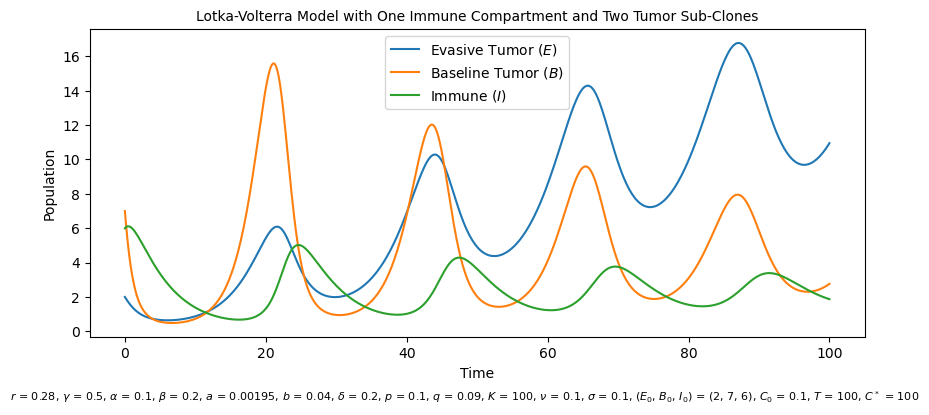

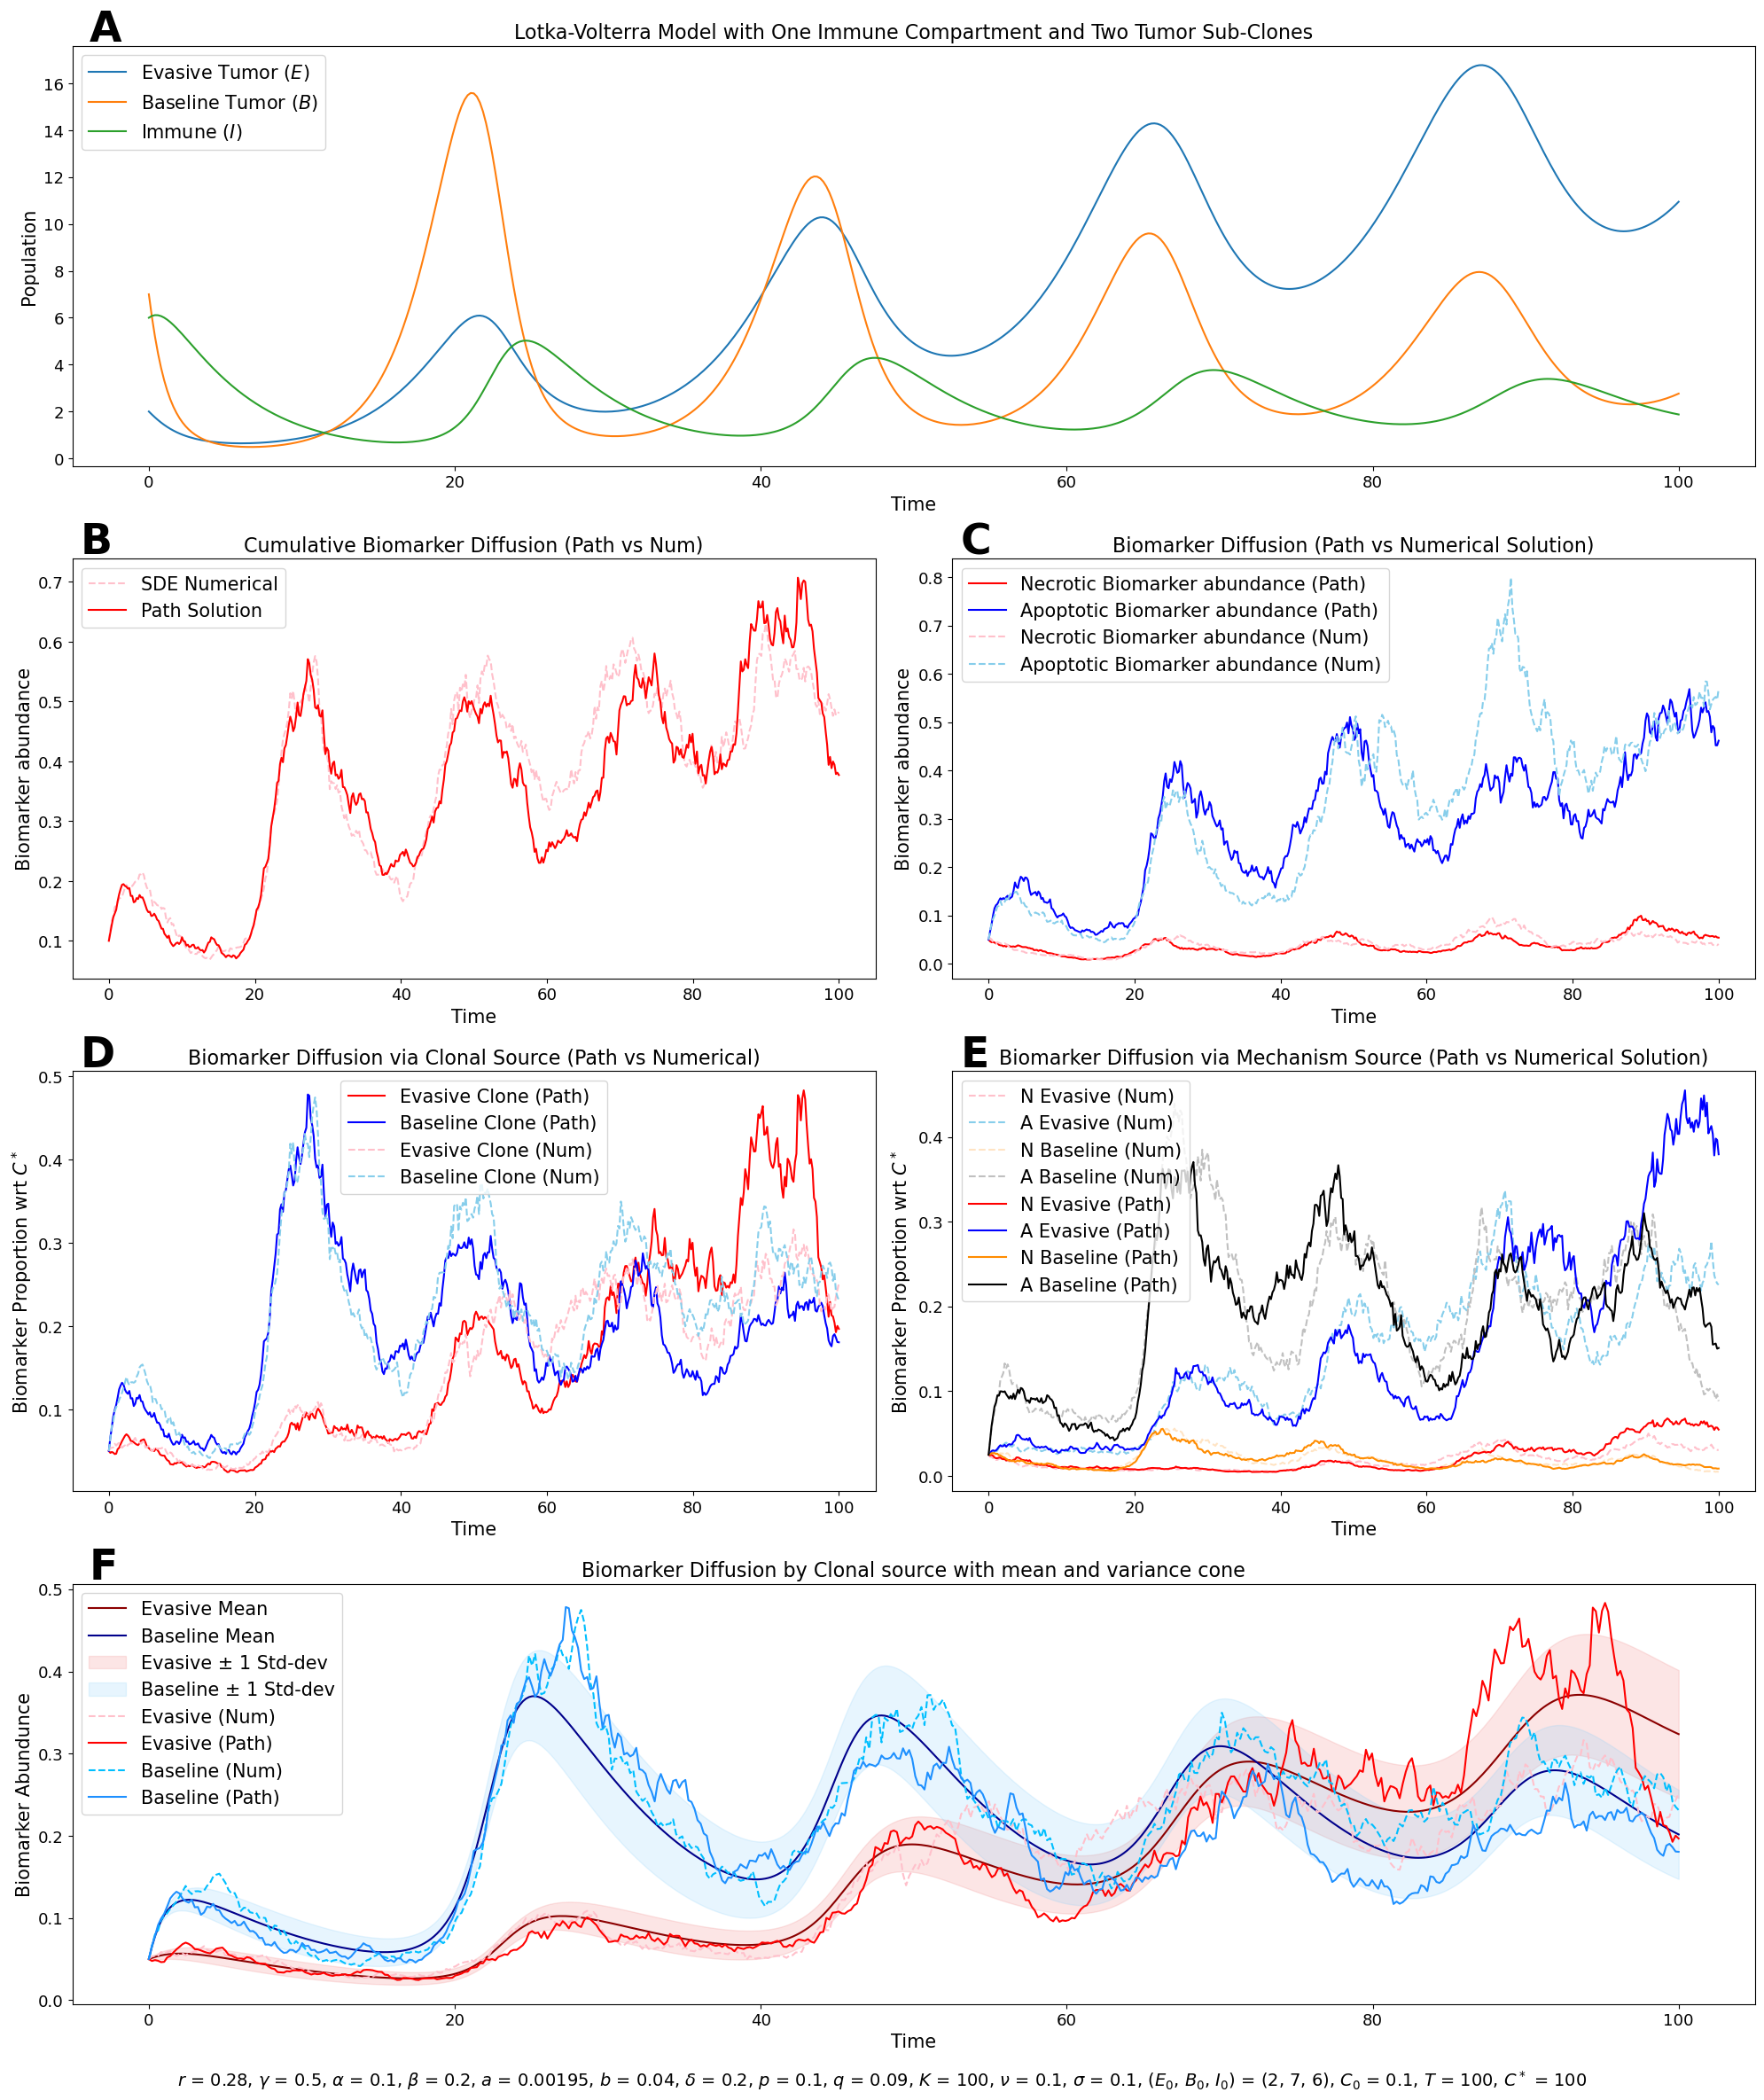

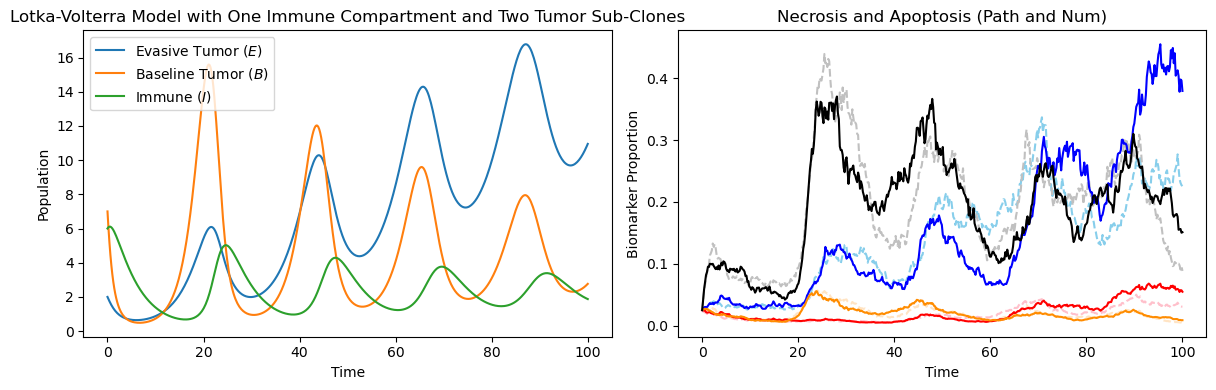

In [3]:
# Create and solve
# ODE parameters
r, gamma, alpha, beta, a, b, delta, p, q, K = [0.28, 0.5, 0.1, 0.2, 0.00195, 0.04, .2, .1, .09, 100]

# ODE Initial Conditions
R_0 = 2
S_0 = 7
I_0 = 6

# Biomarker Decay and Volatility
nu = 0.1
sigma = 0.1

# SDE Initial Conditions
cstar = 100

'''
Important: In order to avoid fake noise, when breaking the initial c_0 concentration into different proportions, we need to ensure that
it sums up to 1. for example, for the all compartments modelling, I assumed every thing is equally split uniformly. 25% apop eva, 
25% necro eva, and the same for baseline. 
'''
inital_proportion_a_n = .5
initial_e_b = .5
C_0 = 10

if sigma**2 > 2* nu:
    logging.info('volatile')
else:
    logging.info('not volatile')
#  Simulation Details
T = 100
steps = 500
plot = True
model = LotkaVolterraModel(r, gamma, alpha, beta, a, b, delta, p,q, K, nu, sigma, R_0, S_0, I_0, C_0 , inital_proportion_a_n ,initial_e_b,T, steps, cstar, plot)



Equilibrium Point Analysis

In [4]:
model.ode_details()

+-----------------------------------------------------------+----------------+----------------+
| Eqpoints                                                  | Existance      | Stability      |
+===========================================================+================+================+
| (0, 0, 0)                                                 | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (0, 100, 0)                                               | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (100, 0, 0)                                               | Exists         | Unstable       |
+-----------------------------------------------------------+----------------+----------------+
| (0, 5.0, 2.375)                                           | Exists         | Unstable       |
+---------------------------------------

,Eqpoints,Existance,Stability
0,"(0, 0, 0)",Exists,Unstable
1,"(0, 100, 0)",Exists,Unstable
2,"(100, 0, 0)",Exists,Unstable
3,"(0, 5.0, 2.375)",Exists,Unstable
4,"(102.56410256410257, 0, -0.07179487179487216)",Does not exist,Does not exist
5,"(90.81735620585268, 91.82643794147326, 0)",Exists,Unstable
6,"(15.31738859022259, 4.253277306226648, 2.359203943016333)",Exists,Stable


Mean hitting time given equilibrium point. Tbh the ode_details is not encompassing for all param combos. As such, you do have to plug in the eq point as a entry for the code below. NOTE: Things can blow up like really large

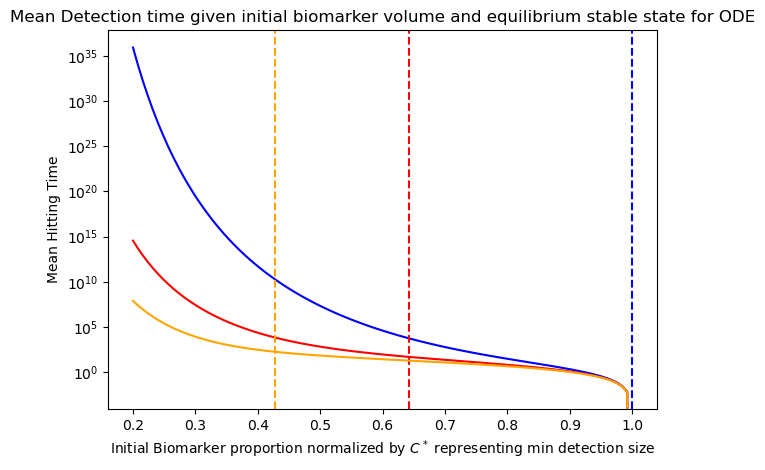

In [6]:
# Mean hitting time [Need to add in the equilibrium state in question.]

plt.figure()
plt.yscale('log')
plt.title('Mean Detection time given initial biomarker volume and equilibrium stable state for ODE')
plt.xlabel('Initial Biomarker proportion normalized by $C^*$ representing min detection size')
plt.ylabel('Mean Hitting Time')
colors = ['blue',"red","orange","green"]
i = 0
eqstate = 	(15.31738859022259, 4.253277306226648, 2.359203943016333)		    
for c_star in ( 50,100,150)	:
    C1_0 = 1/c_star
    model = LotkaVolterraModel(r, gamma, alpha, beta, a, b, delta, p,q, K, nu, sigma, R_0, S_0, I_0, C_0 , inital_proportion_a_n ,initial_e_b,T, steps, c_star, False)
    mean_traj , fstar = model.Mean_return_compartment(eqstate)
    plt.plot(mean_traj.keys(),mean_traj.values() , label = f'$C^*$ = {c_star}', color=colors[i] )
    final_c_at_eq = min(fstar/nu,1)
    plt.axvline(x=final_c_at_eq, color=colors[i], linestyle='--', label = "$C_0$ at eq for $C^*$") 
    i += 1 
# plt.legend()
plt.tight_layout()
plt.show()
#